<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/08_Tree_Based_Algorithms_and_Ensemble_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Tree-Based Algorithms and Ensemble Methods

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 8 membahas algoritma berbasis pohon (tree-based) dan metode ensemble dalam Machine Learning. Decision tree adalah fondasi dari banyak algoritma ML yang paling efektif saat ini. Metode ensemble menggabungkan banyak model lemah menjadi satu model yang lebih kuat melalui tiga strategi utama: **Bagging** (mengurangi variance), **Boosting** (mengurangi bias), dan **Stacking** (menggabungkan prediksi dari berbagai model).

### Topik yang Dibahas:
1. Decision Tree: cara kerja, visualisasi, dan hyperparameter kritis
2. Random Forest dan Bagging
3. Gradient Boosting Machines (GBM)
4. Hyperparameter tuning untuk tree dan ensemble
5. Perbandingan metode ensemble (Bagging, Boosting, Stacking)
6. Latihan praktis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)
print("Library berhasil diimport.")

Library berhasil diimport.


## 1. Decision Tree

### Penjelasan Teori

**Decision Tree** adalah algoritma ML yang membuat keputusan berdasarkan serangkaian aturan if-else yang dipelajari dari data. Pohon dibentuk dengan cara membagi dataset secara rekursif berdasarkan fitur yang memberikan pemisahan terbaik.

**Cara kerja Decision Tree:**
1. Mulai dengan seluruh dataset di root node.
2. Di setiap node, pilih fitur dan threshold yang memaksimalkan "kemurnian" (purity) dari node anak yang dihasilkan.
3. Rekursif membagi data hingga mencapai kondisi berhenti (kedalaman maksimum, jumlah sampel minimum, dll.).
4. Setiap leaf node merepresentasikan kelas prediksi (untuk klasifikasi) atau nilai rata-rata (untuk regresi).

**Metrik impuritas:**
- **Gini Impurity:** Mengukur kemungkinan salah mengklasifikasikan sampel yang dipilih secara acak. Nilai 0 = node murni (satu kelas saja), nilai mendekati 1 = node sangat tidak murni.
- **Entropy:** Alternatif berbasis teori informasi untuk mengukur ketidakmurnian.

**Hyperparameter penting:**
- `max_depth`: Batas kedalaman pohon. Pohon yang terlalu dalam = overfit.
- `min_samples_split`: Jumlah minimum sampel untuk membagi node.
- `min_samples_leaf`: Jumlah minimum sampel di leaf node.
- `max_features`: Jumlah maksimum fitur yang dipertimbangkan di setiap split.

> **Kelemahan utama:** Decision tree tunggal sangat rentan terhadap overfitting. Ini adalah alasan mengapa metode ensemble seperti Random Forest jauh lebih sering digunakan dalam praktik.

In [2]:
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=2024
)

# Latih Decision Tree dengan kedalaman terbatas
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=2024)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree (max_depth=4) - Accuracy: {acc_dt:.4f}")

Decision Tree (max_depth=4) - Accuracy: 0.8667


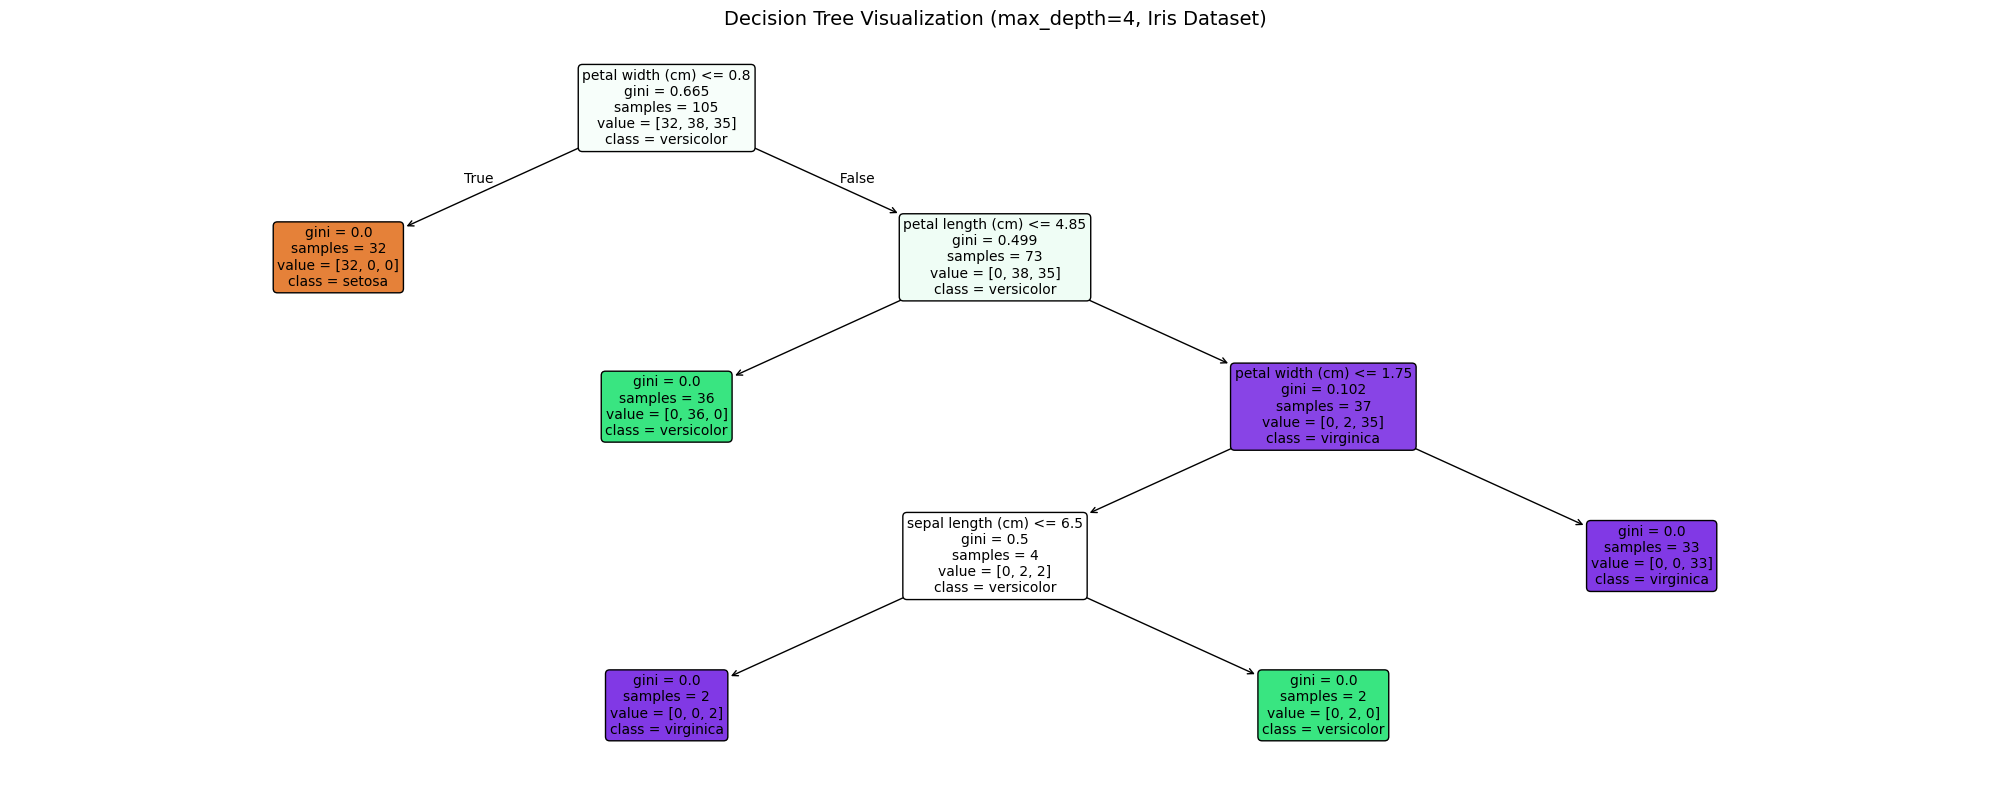

Panduan membaca node:
  gini: ukuran impuritas (0 = murni satu kelas, mendekati 1 = campuran)
  samples: jumlah sampel training di node ini
  value: distribusi sampel per kelas [kelas_0, kelas_1, kelas_2]
  class: kelas mayoritas di node ini


In [3]:
# Visualisasi Decision Tree
plt.figure(figsize=(20, 8))
plot_tree(
    dt_clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True, rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (max_depth=4, Iris Dataset)", fontsize=14)
plt.tight_layout()
plt.show()
print("Panduan membaca node:")
print("  gini: ukuran impuritas (0 = murni satu kelas, mendekati 1 = campuran)")
print("  samples: jumlah sampel training di node ini")
print("  value: distribusi sampel per kelas [kelas_0, kelas_1, kelas_2]")
print("  class: kelas mayoritas di node ini")

In [4]:
# Representasi teks dari Decision Tree
tree_rules = export_text(
    dt_clf, feature_names=list(iris.feature_names)
)
print("Aturan Decision Tree (format teks):")
print(tree_rules)

Aturan Decision Tree (format teks):
|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal length (cm) <= 4.85
|   |   |--- class: 1
|   |--- petal length (cm) >  4.85
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- sepal length (cm) <= 6.50
|   |   |   |   |--- class: 2
|   |   |   |--- sepal length (cm) >  6.50
|   |   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



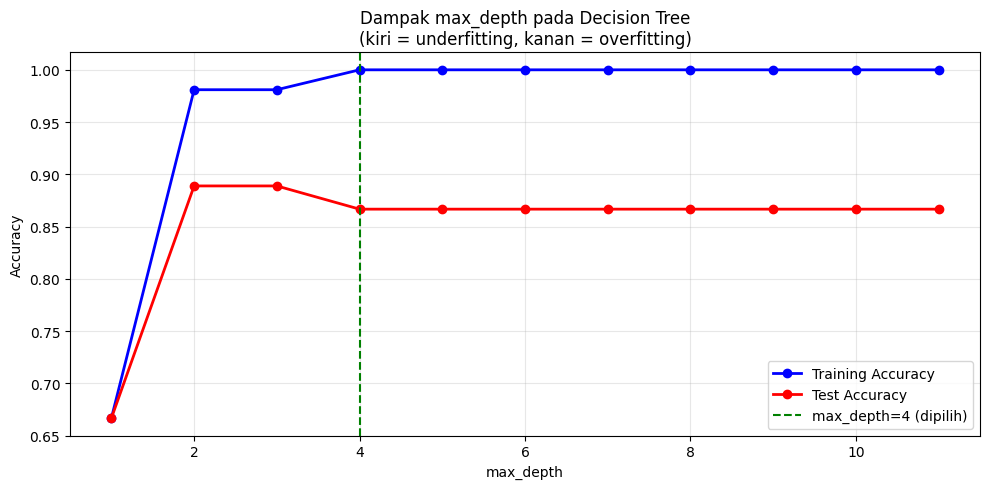

In [5]:
# Dampak max_depth terhadap bias-variance trade-off
depths = range(1, 12)
train_accs, test_accs = [], []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=2024)
    dt.fit(X_train, y_train)
    train_accs.append(dt.score(X_train, y_train))
    test_accs.append(dt.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, 'b-o', linewidth=2, label='Training Accuracy')
plt.plot(depths, test_accs,  'r-o', linewidth=2, label='Test Accuracy')
plt.axvline(x=4, color='green', linestyle='--', label='max_depth=4 (dipilih)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Dampak max_depth pada Decision Tree\n(kiri = underfitting, kanan = overfitting)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Random Forest dan Bagging

### Penjelasan Teori

**Random Forest** adalah metode ensemble yang menggabungkan banyak decision tree untuk meningkatkan akurasi dan mengurangi overfitting melalui teknik **Bootstrap Aggregating (Bagging)**.

**Cara kerja Random Forest:**
1. Buat N decision tree, masing-masing dilatih pada subset data training yang disampling **dengan penggantian** (bootstrap sample).
2. Pada setiap split di setiap tree, hanya subset acak dari fitur yang dipertimbangkan (ini yang membedakan Random Forest dari Bagging biasa).
3. Setiap tree memberikan "vote" prediksinya.
4. Prediksi akhir adalah mayoritas vote (klasifikasi) atau rata-rata (regresi).

**Mengapa lebih baik dari single tree:**
- **Bagging mengurangi variance:** Dengan merata-ratakan banyak model yang beragam, variasi prediksi berkurang secara signifikan.
- **Pemilihan fitur acak menambah diversitas:** Mencegah semua pohon terlalu mirip satu sama lain.
- **Feature importance:** Random Forest secara otomatis memberikan skor kepentingan setiap fitur, berguna untuk seleksi fitur.

**Hyperparameter penting:**
- `n_estimators`: Jumlah pohon. Lebih banyak = lebih baik, tapi lebih lambat.
- `max_features`: Jumlah fitur yang dipertimbangkan di setiap split.
- `max_depth`: Kedalaman maksimum setiap tree.

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Latih Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest (100 trees) - Accuracy: {acc_rf:.4f}")
print(f"Decision Tree (1 tree)    - Accuracy: {acc_dt:.4f}")
print(f"Peningkatan accuracy: {acc_rf - acc_dt:+.4f}")

Random Forest (100 trees) - Accuracy: 0.9111
Decision Tree (1 tree)    - Accuracy: 0.8667
Peningkatan accuracy: +0.0444


In [7]:
# Classification report
report_rf = pd.DataFrame(
    classification_report(y_test, y_pred_rf, target_names=iris.target_names, output_dict=True)
).transpose()
print("Classification Report - Random Forest:")
display(report_rf.round(4))

Classification Report - Random Forest:


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,18.0000
versicolor,0.8333,0.8333,0.8333,12.0000
virginica,0.8667,0.8667,0.8667,15.0000
accuracy,0.9111,0.9111,0.9111,0.9111
macro avg,0.9000,0.9000,0.9000,45.0000
weighted avg,0.9111,0.9111,0.9111,45.0000


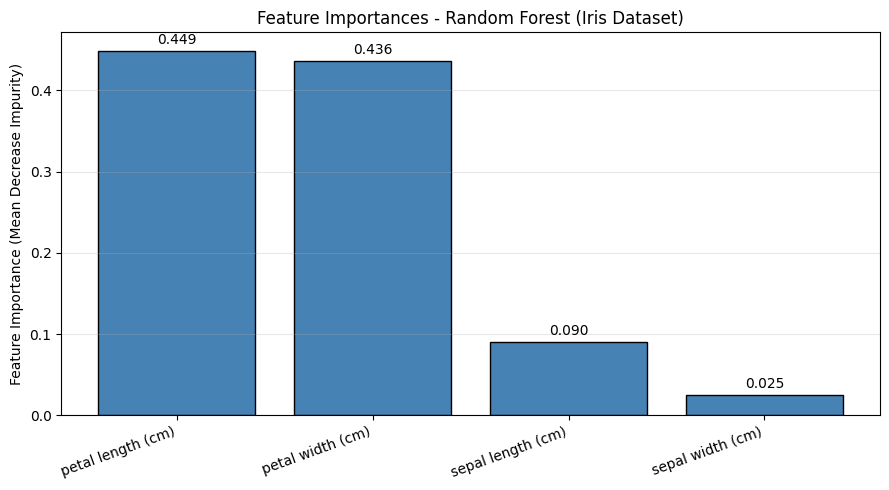

Fitur dengan importance tertinggi paling berpengaruh dalam pemisahan kelas.
Random Forest juga bisa digunakan hanya untuk seleksi fitur.


In [8]:
# Visualisasi Feature Importance
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]  # Urutkan dari terbesar ke terkecil

plt.figure(figsize=(9, 5))
bars = plt.bar(range(len(iris.feature_names)), importances[indices],
               color='steelblue', edgecolor='black')
plt.xticks(range(len(iris.feature_names)),
           [iris.feature_names[i] for i in indices], rotation=20, ha='right')
plt.ylabel('Feature Importance (Mean Decrease Impurity)')
plt.title('Feature Importances - Random Forest (Iris Dataset)')

for bar, val in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("Fitur dengan importance tertinggi paling berpengaruh dalam pemisahan kelas.")
print("Random Forest juga bisa digunakan hanya untuk seleksi fitur.")

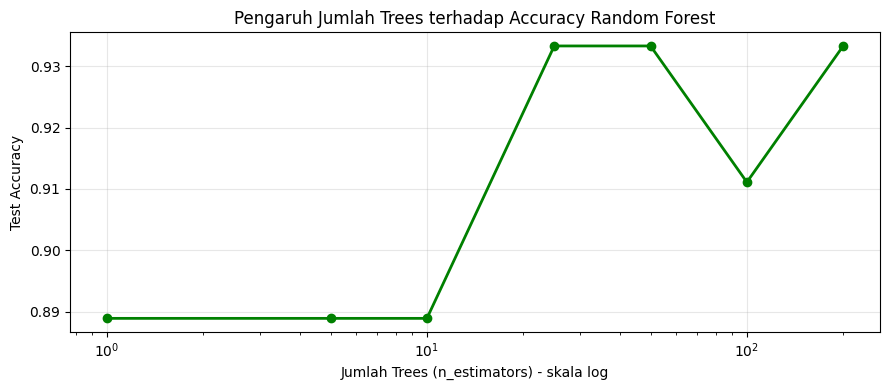

In [9]:
# Pengaruh n_estimators terhadap performa
n_est_range = [1, 5, 10, 25, 50, 100, 200]
scores_n_est = []

for n_est in n_est_range:
    rf_temp = RandomForestClassifier(n_estimators=n_est, random_state=2024)
    rf_temp.fit(X_train, y_train)
    scores_n_est.append(rf_temp.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.semilogx(n_est_range, scores_n_est, 'g-o', linewidth=2)
plt.xlabel('Jumlah Trees (n_estimators) - skala log')
plt.ylabel('Test Accuracy')
plt.title('Pengaruh Jumlah Trees terhadap Accuracy Random Forest')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Gradient Boosting Machines (GBM)

### Penjelasan Teori

**Gradient Boosting** adalah teknik ensemble yang membangun model secara **sekuensial**, di mana setiap model baru berfokus pada memperbaiki kesalahan (residuals) dari model sebelumnya. Inilah perbedaan utama dari Random Forest yang membangun pohon secara paralel.

**Cara kerja GBM:**
1. Mulai dengan prediksi awal yang sederhana (biasanya rata-rata target).
2. Hitung residuals (selisih prediksi vs aktual).
3. Latih pohon baru untuk memprediksi residuals tersebut.
4. Tambahkan pohon baru ke model dengan bobot yang dikontrol oleh `learning_rate`.
5. Ulangi langkah 2-4 sebanyak `n_estimators` kali.

**Hyperparameter kritis GBM:**
- `n_estimators`: Jumlah tahap boosting (jumlah pohon).
- `learning_rate`: Mengontrol kontribusi setiap pohon. Nilai kecil = lebih banyak pohon diperlukan, tapi performa biasanya lebih baik.
- `max_depth`: Kedalaman setiap pohon (biasanya 3-5 untuk GBM).
- `subsample`: Proporsi sampel yang digunakan untuk setiap tahap (menambah stokastisitas).

**Early Stopping:** Teknik yang membatasi proses iterasi untuk menghindari overfitting. Model berhenti dilatih saat performa pada validation set mulai memburuk.

**Validation Curves:** Visualisasi yang membantu mengidentifikasi apakah model underfitting atau overfitting berdasarkan performa pada training dan validation set.

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

# Latih GBM
gbm_clf = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=3, random_state=2024
)
gbm_clf.fit(X_train, y_train)
y_pred_gbm = gbm_clf.predict(X_test)
acc_gbm = accuracy_score(y_test, y_pred_gbm)

print(f"GBM (200 estimators, lr=0.1) - Accuracy: {acc_gbm:.4f}")

GBM (200 estimators, lr=0.1) - Accuracy: 0.8667


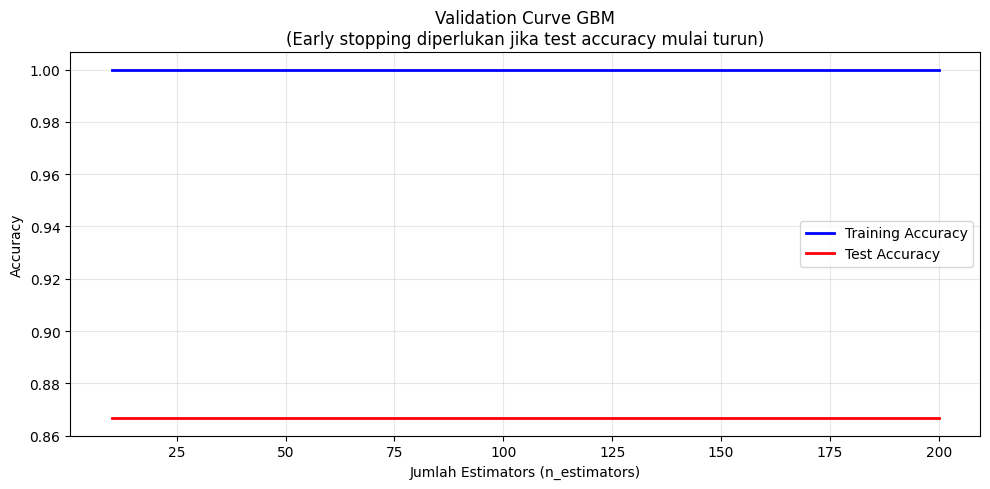

In [11]:
# Validation curve: performa train vs test per iterasi GBM
train_scores_iter = []
test_scores_iter  = []

for n_est in range(10, 210, 10):
    gbm_temp = GradientBoostingClassifier(
        n_estimators=n_est, learning_rate=0.1,
        max_depth=3, random_state=2024
    )
    gbm_temp.fit(X_train, y_train)
    train_scores_iter.append(gbm_temp.score(X_train, y_train))
    test_scores_iter.append(gbm_temp.score(X_test, y_test))

n_est_range_iter = range(10, 210, 10)
plt.figure(figsize=(10, 5))
plt.plot(n_est_range_iter, train_scores_iter, 'b-', linewidth=2, label='Training Accuracy')
plt.plot(n_est_range_iter, test_scores_iter,  'r-', linewidth=2, label='Test Accuracy')
plt.xlabel('Jumlah Estimators (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Validation Curve GBM\n(Early stopping diperlukan jika test accuracy mulai turun)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning untuk Trees dan Ensembles

### Penjelasan Teori

Hyperparameter tuning adalah proses menemukan kombinasi hyperparameter terbaik untuk memaksimalkan performa model pada data yang belum dilihat.

**Dua pendekatan utama:**

1. **GridSearchCV:** Mencoba semua kombinasi hyperparameter yang ditentukan secara exhaustive. Lebih lambat tapi menjamin menemukan kombinasi terbaik di dalam grid yang ditetapkan.

2. **RandomizedSearchCV:** Mengambil sampel acak dari ruang hyperparameter. Lebih cepat dan seringkali memberikan hasil yang tidak kalah baik dari GridSearchCV, terutama ketika ruang pencarian sangat besar.

**Visualisasi hasil tuning:**
Heatmap dari `cv_results_` membantu memahami interaksi antar hyperparameter dan menentukan area yang paling menjanjikan dalam ruang hyperparameter.

In [12]:
from sklearn.model_selection import GridSearchCV

# Definisikan grid hyperparameter untuk GBM
param_grid_gbm = {
    'n_estimators':  [50, 100, 150],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

gs_gbm = GridSearchCV(
    GradientBoostingClassifier(random_state=2024),
    param_grid_gbm, cv=5,
    scoring='accuracy', n_jobs=-1
)
gs_gbm.fit(X_train, y_train)

print(f"Parameter terbaik (GBM):    {gs_gbm.best_params_}")
print(f"CV Accuracy terbaik:        {gs_gbm.best_score_:.4f}")
print(f"Accuracy pada test set:     {gs_gbm.best_estimator_.score(X_test, y_test):.4f}")

Parameter terbaik (GBM):    {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50}
CV Accuracy terbaik:        0.9810
Accuracy pada test set:     0.8667


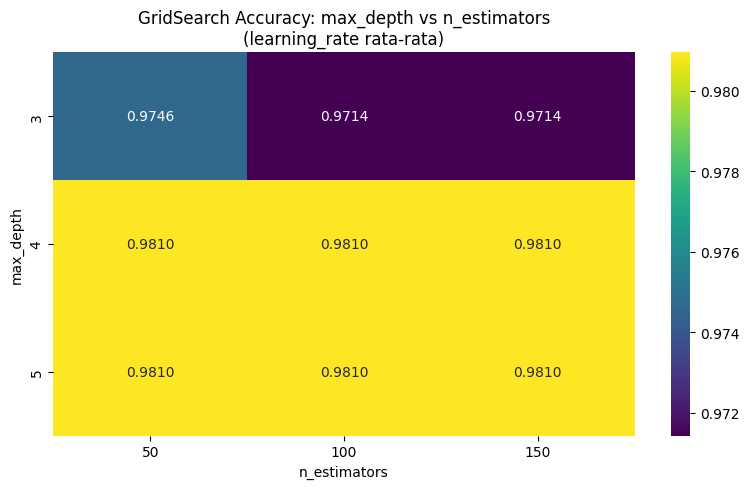

In [13]:
# Heatmap hasil GridSearch: max_depth vs n_estimators
results_gs = pd.DataFrame(gs_gbm.cv_results_)
pivot = results_gs.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis')
plt.title('GridSearch Accuracy: max_depth vs n_estimators\n(learning_rate rata-rata)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# RandomizedSearchCV untuk Random Forest (ruang pencarian lebih besar)
param_dist_rf = {
    'n_estimators': randint(50, 300),
    'max_depth':    randint(3, 15),
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': randint(2, 10),
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=2024),
    param_dist_rf, n_iter=30, cv=5,
    scoring='accuracy', random_state=2024, n_jobs=-1
)
rs_rf.fit(X_train, y_train)

print(f"Parameter terbaik (RF - RandomizedSearch): {rs_rf.best_params_}")
print(f"CV Accuracy terbaik:                       {rs_rf.best_score_:.4f}")
print(f"Accuracy pada test set:                    {rs_rf.best_estimator_.score(X_test, y_test):.4f}")

Parameter terbaik (RF - RandomizedSearch): {'max_depth': 11, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 178}
CV Accuracy terbaik:                       0.9714
Accuracy pada test set:                    0.8889


## 5. Perbandingan Metode Ensemble

### Penjelasan Teori

Tiga strategi utama ensemble learning:

| Strategi | Teknik | Cara Kerja | Mengurangi | Cocok Untuk |
|----------|--------|-----------|-----------|-------------|
| **Bagging** | Random Forest, BaggingClassifier | Pohon paralel pada bootstrap samples | Variance | Data dengan overfitting tinggi |
| **Boosting** | GBM, AdaBoost | Pohon sekuensial, fokus pada kesalahan | Bias | Data kompleks dengan pola non-linear |
| **Stacking** | StackingClassifier | Meta-model menggabungkan prediksi base models | Keduanya | Tugas kompleks dengan data berlimpah |

**Stacking (Stacked Generalization):**
- **Level 0 (Base Models):** Beberapa model dilatih pada data training.
- **Level 1 (Meta-Model):** Model kedua (biasanya sederhana seperti Logistic Regression) dilatih pada prediksi dari base models.
- Tujuannya: memanfaatkan kekuatan masing-masing base model yang berbeda.

In [16]:
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier, BaggingClassifier, AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Definisikan semua model
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=2024),
    'Bagging (Random Forest)': RandomForestClassifier(n_estimators=100, random_state=2024),
    'Boosting (GBM)': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=2024),
    'Boosting (AdaBoost)': AdaBoostClassifier(n_estimators=100, random_state=2024),
    'Stacking': StackingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=2024)),
            ('gbm', GradientBoostingClassifier(n_estimators=100, random_state=2024))
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5
    ),
}

results_ensemble = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results_ensemble[name] = model.score(X_test, y_test)
    print(f"{name:<30} Accuracy: {results_ensemble[name]:.4f}")

Decision Tree                  Accuracy: 0.8667
Bagging (Random Forest)        Accuracy: 0.9111
Boosting (GBM)                 Accuracy: 0.8667
Boosting (AdaBoost)            Accuracy: 0.8889
Stacking                       Accuracy: 0.8667


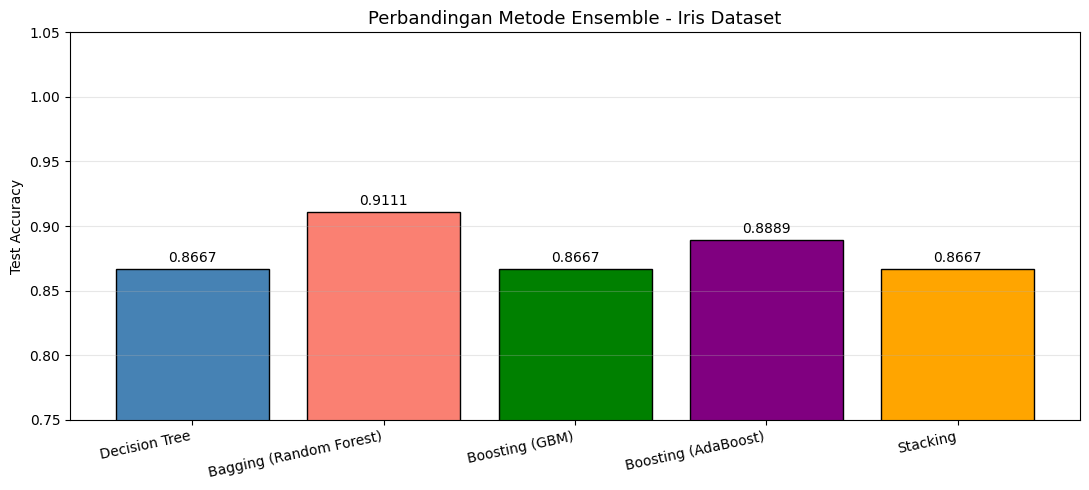

In [17]:
# Visualisasi perbandingan semua ensemble
fig, ax = plt.subplots(figsize=(11, 5))
names   = list(results_ensemble.keys())
accs    = list(results_ensemble.values())
colors  = ['steelblue', 'salmon', 'green', 'purple', 'orange']

bars = ax.bar(names, accs, color=colors, edgecolor='black')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0.75, 1.05)
ax.set_ylabel('Test Accuracy')
ax.set_title('Perbandingan Metode Ensemble - Iris Dataset', fontsize=13)
ax.set_xticklabels(names, rotation=12, ha='right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 6. Latihan Praktis: Tree-Based Models pada Breast Cancer Dataset

### Deskripsi

Pada bagian ini kita menerapkan semua teknik yang dipelajari pada dataset Breast Cancer (binary classification). Kita membandingkan Decision Tree, Random Forest, GBM, dan Stacking, lalu melakukan tuning hyperparameter pada model terbaik.

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

# Load dataset
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

print(f"Dataset: Breast Cancer Wisconsin")
print(f"Shape: {X_bc.shape}")
print(f"Kelas: {bc.target_names} | Distribusi: {np.bincount(y_bc)}")

Dataset: Breast Cancer Wisconsin
Shape: (569, 30)
Kelas: ['malignant' 'benign'] | Distribusi: [212 357]


In [19]:
# Bandingkan semua model tree-based
from sklearn.metrics import roc_auc_score

bc_models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GBM':           GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'Stacking':      StackingClassifier(
        estimators=[
            ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5
    ),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
bc_summary = []

for name, model in bc_models.items():
    cv_acc = cross_val_score(model, X_bc_train, y_bc_train, cv=kf, scoring='accuracy')
    model.fit(X_bc_train, y_bc_train)
    y_pred_bc = model.predict(X_bc_test)
    y_prob_bc = (model.predict_proba(X_bc_test)[:, 1]
                 if hasattr(model, 'predict_proba') else None)
    test_acc = accuracy_score(y_bc_test, y_pred_bc)
    auc_val  = roc_auc_score(y_bc_test, y_prob_bc) if y_prob_bc is not None else None

    bc_summary.append({
        'Model': name,
        'CV Accuracy Mean': round(cv_acc.mean(), 4),
        'CV Accuracy Std':  round(cv_acc.std(), 4),
        'Test Accuracy':    round(test_acc, 4),
        'Test ROC-AUC':     round(auc_val, 4) if auc_val else 'N/A'
    })
    print(f"{name:<20} CV Acc: {cv_acc.mean():.4f} | Test Acc: {test_acc:.4f}")

print()
display(pd.DataFrame(bc_summary))

Decision Tree        CV Acc: 0.9011 | Test Acc: 0.9474
Random Forest        CV Acc: 0.9560 | Test Acc: 0.9649
GBM                  CV Acc: 0.9451 | Test Acc: 0.9561
Stacking             CV Acc: 0.9407 | Test Acc: 0.9561



,Model,CV Accuracy Mean,CV Accuracy Std,Test Accuracy,Test ROC-AUC
0,Decision Tree,0.9011,0.0184,0.9474,0.9355
1,Random Forest,0.9560,0.0197,0.9649,0.9953
2,GBM,0.9451,0.0197,0.9561,0.9951
3,Stacking,0.9407,0.0149,0.9561,0.9944


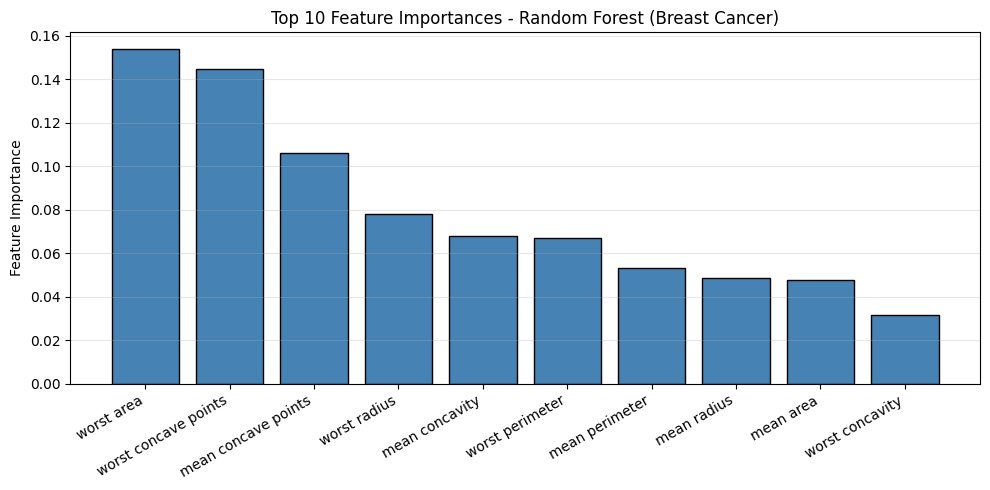

In [20]:
# Feature importance dari Random Forest pada Breast Cancer
rf_bc = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bc.fit(X_bc_train, y_bc_train)

imp = rf_bc.feature_importances_
top_n = 10
top_idx = np.argsort(imp)[-top_n:][::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), imp[top_idx], color='steelblue', edgecolor='black')
plt.xticks(range(top_n), [bc.feature_names[i] for i in top_idx], rotation=30, ha='right')
plt.ylabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importances - Random Forest (Breast Cancer)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Ringkasan Chapter 8

| Model | Kelas scikit-learn | Strategi | Kelebihan |
|-------|-------------------|---------|-----------|
| Decision Tree | `DecisionTreeClassifier()` | Single tree | Mudah diinterpretasikan |
| Random Forest | `RandomForestClassifier()` | Bagging | Robust terhadap overfitting, feature importance |
| GBM | `GradientBoostingClassifier()` | Boosting | Performa tinggi pada data kompleks |
| AdaBoost | `AdaBoostClassifier()` | Boosting | Fokus pada sampel yang sulit diklasifikasikan |
| Stacking | `StackingClassifier()` | Stacking | Menggabungkan kekuatan berbagai model |

### Poin Kunci untuk Diingat:

1. **Decision Tree tunggal sangat rentan terhadap overfitting.** Selalu atur `max_depth` atau hyperparameter lain untuk mengontrol kompleksitas.

2. **Bagging (Random Forest) mengurangi variance:** Melatih banyak pohon pada bootstrap samples yang berbeda, lalu mengambil rata-rata prediksi.

3. **Boosting (GBM) mengurangi bias:** Setiap pohon baru berfokus pada memperbaiki kesalahan pohon sebelumnya. Lebih sensitif terhadap noise dan outlier dibanding Random Forest.

4. **Feature importance dari Random Forest** sangat berguna untuk pemahaman dan seleksi fitur, tapi bisa bias pada fitur dengan banyak kategori (high cardinality).

5. **Gunakan `GridSearchCV` atau `RandomizedSearchCV`** untuk tuning hyperparameter. Untuk ruang pencarian besar, `RandomizedSearchCV` biasanya lebih efisien.

6. **Stacking** bisa memberikan peningkatan performa tambahan, tapi jauh lebih kompleks dan memerlukan lebih banyak data untuk bekerja dengan baik.